# 🧠 Notebook 02: Embeddings & FAISS Index

This notebook generates semantic embeddings and builds a FAISS vector index.

**Steps:**
1. Load processed papers from Notebook 01
2. Generate embeddings with SentenceTransformers
3. Build and save FAISS index
4. Demo: run semantic searches

In [8]:
import sys
sys.path.insert(0, '..')

import os
import numpy as np
import pandas as pd
from src.data_loader import load_processed_data, load_arxiv_data, save_processed_data
from src.embedder import EmbeddingModel, save_embeddings, load_embeddings, MODELS
from src.vector_store import FAISSVectorStore
from src.retriever import SemanticRetriever
from src.utils import setup_logging, get_arxiv_url

setup_logging('INFO')
print('Setup complete!')
print(f'Available models: {list(MODELS.keys())}')

Setup complete!
Available models: ['all-MiniLM-L6-v2', 'nomic-embed-text-v1', 'all-mpnet-base-v2']


## 1. Load Processed Data

In [9]:
DATA_PATH = '../data/papers_processed.parquet'

# If processed data doesn't exist, create it
if not os.path.exists(DATA_PATH):
    print('Processed data not found. Loading from raw JSON...')
    RAW_PATH = '../../arxiv-metadata-oai-snapshot.json'
    df = load_arxiv_data(RAW_PATH, max_records=50000, cs_only=True)
    os.makedirs('../data', exist_ok=True)
    save_processed_data(df, DATA_PATH)
else:
    df = load_processed_data(DATA_PATH)

print(f'Papers loaded: {len(df)}')
print(f'Sample text: {df.iloc[0]["text"][:200]}...')

14:56:02 | src.data_loader | INFO | Loaded processed data from ../data/papers_processed.parquet (50000 records)


Papers loaded: 50000
Sample text: Sparsity-certifying Graph Decompositions We describe a new algorithm, the $(k,\ell)$-pebble game with colors, and use it obtain a characterization of the family of $(k,\ell)$-sparse graphs and algorit...


## 2. Generate Embeddings

Using `all-MiniLM-L6-v2` — a fast, high-quality 384-dimensional model.

In [10]:
EMBEDDINGS_PATH = '../data/embeddings.npy'
MODEL_NAME = 'all-MiniLM-L6-v2'

# Load or generate embeddings
if os.path.exists(EMBEDDINGS_PATH):
    print('Loading pre-computed embeddings...')
    embeddings = load_embeddings(EMBEDDINGS_PATH)
else:
    print('Generating embeddings (this may take a few minutes)...')
    model = EmbeddingModel(MODEL_NAME)
    
    texts = df['text'].tolist()
    embeddings = model.encode_texts(texts, batch_size=64, show_progress=True)
    
    # Save embeddings
    save_embeddings(embeddings, EMBEDDINGS_PATH, metadata={
        'model': MODEL_NAME,
        'num_papers': len(df),
        'dimension': embeddings.shape[1],
    })

print(f'\nEmbeddings shape: {embeddings.shape}')
print(f'Embedding dimension: {embeddings.shape[1]}')
print(f'Memory: {embeddings.nbytes / 1e6:.1f} MB')

14:56:02 | src.embedder | INFO | Loaded embeddings from ../data/embeddings.npy (shape: (50000, 384))


Loading pre-computed embeddings...

Embeddings shape: (50000, 384)
Embedding dimension: 384
Memory: 76.8 MB


## 3. Build FAISS Index

In [11]:
INDEX_DIR = '../data/index'

# Prepare metadata (one dict per paper)
metadata_list = df.to_dict('records')
print(f'Metadata prepared for {len(metadata_list)} papers')

# Build FAISS index
dimension = embeddings.shape[1]
store = FAISSVectorStore(dimension=dimension)

# Use 'flat' for exact search (best for < 100k papers)
# Use 'ivf' for approximate search (faster for larger datasets)
index_type = 'flat' if len(df) < 100000 else 'ivf'
print(f'Building {index_type} index...')

store.build_index(embeddings, metadata_list, index_type=index_type)
print(f'Index built: {store.size} vectors')

# Save index
store.save_index(INDEX_DIR)
print(f'Index saved to {INDEX_DIR}/')

14:56:02 | src.vector_store | INFO | Building IndexFlatIP (exact search)...
14:56:02 | src.vector_store | INFO | Index built: 50000 vectors, type=flat
14:56:02 | src.vector_store | INFO | Index saved to ../data/index/faiss_index*


Metadata prepared for 50000 papers
Building flat index...
Index built: 50000 vectors
Index saved to ../data/index/


## 4. Demo: Semantic Search

In [12]:
# Initialize retriever
embedder = EmbeddingModel(MODEL_NAME)
retriever = SemanticRetriever(embedder, store)

# Demo queries
demo_queries = [
    'attention mechanisms in transformer architectures',
    'generative adversarial networks for image synthesis',
    'reinforcement learning for playing games',
    'federated learning with differential privacy',
    'graph neural networks for drug discovery',
]

for query in demo_queries:
    print(f'\n{"="*80}')
    print(f'🔍 Query: "{query}"')
    print('=' * 80)
    
    results = retriever.search(query, top_k=3)
    
    for r in results:
        meta = r['metadata']
        print(f'\n  #{r["rank"]} (score: {r["score"]:.4f})')
        print(f'  📄 {meta["title"]}')
        print(f'  🏷️  {meta["primary_category"]} | 📅 {meta.get("year", "N/A")}')
        print(f'  🔗 {get_arxiv_url(meta["id"])}')
        abstract_preview = meta['abstract'][:150] + '...' if len(meta['abstract']) > 150 else meta['abstract']
        print(f'  📝 {abstract_preview}')

14:56:02 | src.embedder | INFO | Loading embedding model: sentence-transformers/all-MiniLM-L6-v2
14:56:02 | sentence_transformers.SentenceTransformer | INFO | Use pytorch device_name: mps
14:56:02 | sentence_transformers.SentenceTransformer | INFO | Load pretrained SentenceTransformer: sentence-transformers/all-MiniLM-L6-v2
14:56:07 | src.embedder | INFO | Model loaded. Embedding dimension: 384



🔍 Query: "attention mechanisms in transformer architectures"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

14:56:07 | src.retriever | INFO | Query: 'attention mechanisms in transformer architectures...' → 3 results (from 3 candidates)



  #1 (score: 0.5663)
  📄 6th International Symposium on Attention in Cognitive Systems 2013
  🏷️  cs.CV | 📅 2013
  🔗 https://arxiv.org/abs/1307.6170
  📝 This volume contains the papers accepted at the 6th International Symposium on Attention in Cognitive Systems (ISACS 2013), held in Beijing, August 5,...

  #2 (score: 0.5200)
  📄 A computational approach to the covert and overt deployment of spatial attention
  🏷️  cs.NE | 📅 2008
  🔗 https://arxiv.org/abs/0809.4622
  📝 Popular computational models of visual attention tend to neglect the influence of saccadic eye movements whereas it has been shown that the primates p...

  #3 (score: 0.4817)
  📄 A Prototyping Environment for Integrated Artificial Attention Systems
  🏷️  cs.CV | 📅 2013
  🔗 https://arxiv.org/abs/1307.8233
  📝 Artificial visual attention systems aim to support technical systems in visual tasks by applying the concepts of selective attention observed in human...

🔍 Query: "generative adversarial networks for image synthe

...

14:56:07 | src.retriever | INFO | Query: 'federated learning with differential privacy...' → 3 results (from 3 candidates)



  #1 (score: 0.6303)
  📄 Random Differential Privacy
  🏷️  stat.ME | 📅 2011
  🔗 https://arxiv.org/abs/1112.2680
  📝 We propose a relaxed privacy definition called {\em random differential privacy} (RDP). Differential privacy requires that adding any new observation ...

  #2 (score: 0.6259)
  📄 On the `Semantics' of Differential Privacy: A Bayesian Formulation
  🏷️  cs.CR | 📅 2023
  🔗 https://arxiv.org/abs/0803.3946
  📝 Differential privacy is a definition of "privacy'" for algorithms that analyze and publish information about statistical databases. It is often claime...

  #3 (score: 0.6233)
  📄 Privacy Aware Learning
  🏷️  stat.ML | 📅 2013
  🔗 https://arxiv.org/abs/1210.2085
  📝 We study statistical risk minimization problems under a privacy model in which the data is kept confidential even from the learner. In this local priv...

🔍 Query: "graph neural networks for drug discovery"


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

14:56:07 | src.retriever | INFO | Query: 'graph neural networks for drug discovery...' → 3 results (from 3 candidates)



  #1 (score: 0.6926)
  📄 Some Perspectives on Network Modeling in Therapeutic Target Prediction
  🏷️  q-bio.MN | 📅 2013
  🔗 https://arxiv.org/abs/1307.7385
  📝 Drug target identification is of significant commercial interest to pharmaceutical companies, and there is a vast amount of research done related to t...

  #2 (score: 0.6587)
  📄 Graph theory enables drug repurposing. How a mathematical model can drive the discovery of hidden Mechanisms of Action
  🏷️  q-bio.QM | 📅 2014
  🔗 https://arxiv.org/abs/1306.0924
  📝 We introduced a methodology to efficiently exploit natural-language expressed biomedical knowledge for repurposing existing drugs towards diseases for...

  #3 (score: 0.6175)
  📄 Structure and dynamics of molecular networks: A novel paradigm of drug discovery. A comprehensive review
  🏷️  q-bio.MN | 📅 2013
  🔗 https://arxiv.org/abs/1210.0330
  📝 Despite considerable progress in genome- and proteome-based high-throughput screening methods and in rational drug design, the 

## 5. Embedding Space Visualization (Optional)

Visualize the embedding space using t-SNE to see how papers cluster by category.

/Users/santoshkumarsinha/Library/Python/3.9/lib/python/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Running t-SNE (this may take 1-2 minutes)...


/var/folders/t1/96jc2yg1499glgqdjgf0285h0000gn/T/ipykernel_31582/1917147788.py:29: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=50) for i in range(len(legend_labels))]


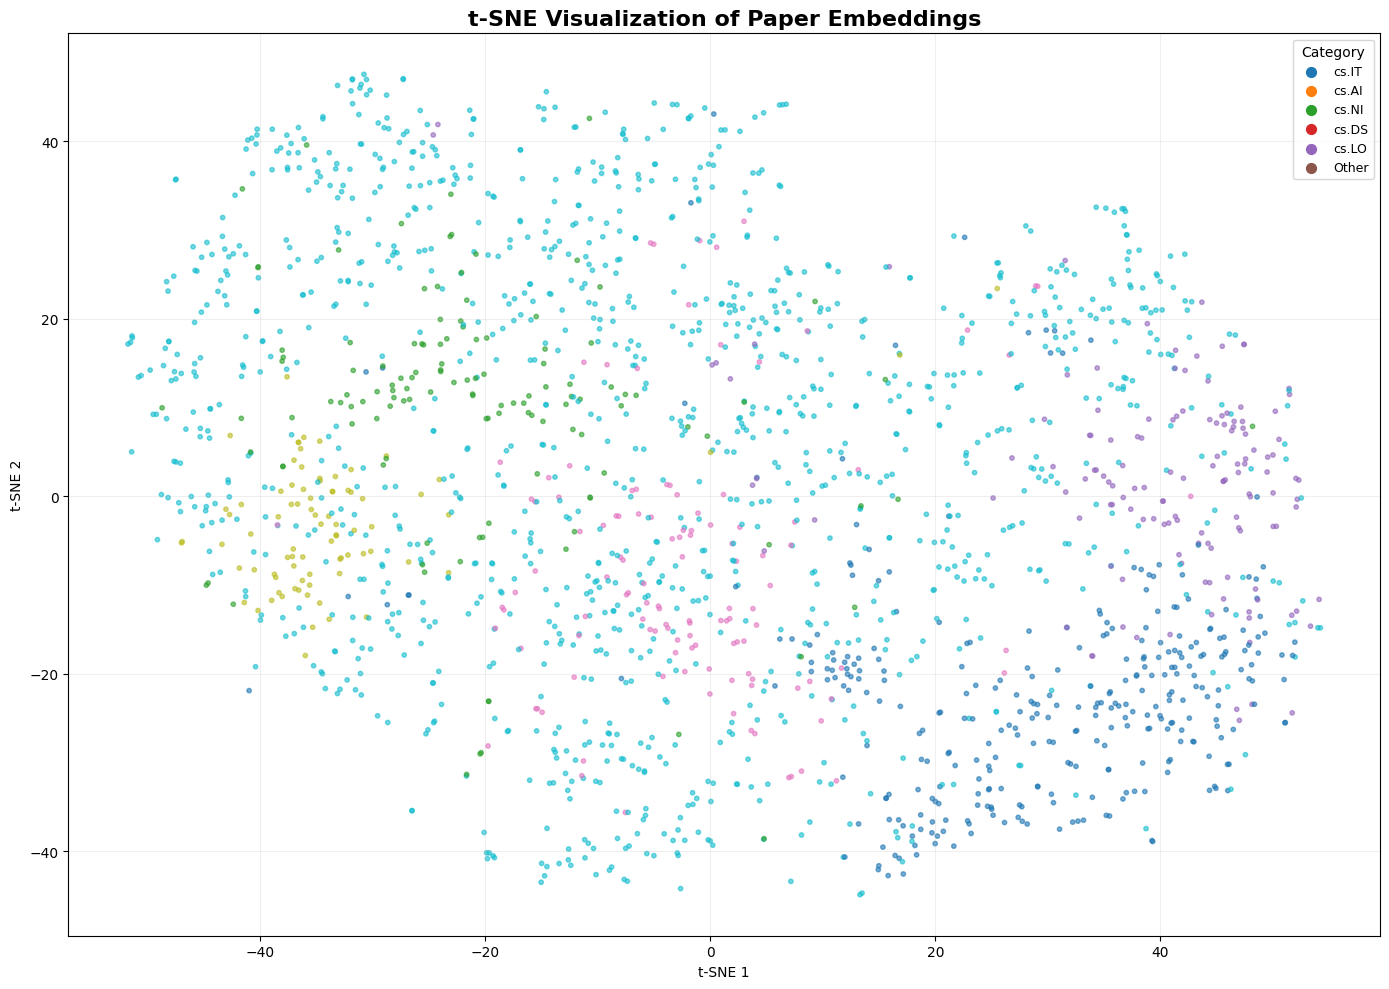

Papers cluster by topic! Semantic embeddings capture meaning effectively.


In [13]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Sample a subset for visualization (t-SNE is slow on large datasets)
SAMPLE_SIZE = 2000
np.random.seed(42)
sample_idx = np.random.choice(len(df), min(SAMPLE_SIZE, len(df)), replace=False)
sample_embeddings = embeddings[sample_idx]
sample_categories = df.iloc[sample_idx]['primary_category'].values

# Get top 5 categories for coloring
top_cats = df['primary_category'].value_counts().head(5).index.tolist()
cat_colors = [top_cats.index(c) if c in top_cats else 5 for c in sample_categories]

# t-SNE
print('Running t-SNE (this may take 1-2 minutes)...')
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
coords = tsne.fit_transform(sample_embeddings)

# Plot
fig, ax = plt.subplots(figsize=(14, 10))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=cat_colors, cmap='tab10', alpha=0.6, s=10
)

# Legend
legend_labels = top_cats + ['Other']
handles = [plt.scatter([], [], c=plt.cm.tab10(i/10), s=50) for i in range(len(legend_labels))]
ax.legend(handles, legend_labels, title='Category', loc='best', fontsize=9)

ax.set_title('t-SNE Visualization of Paper Embeddings', fontsize=16, fontweight='bold')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig('../data/tsne_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print('Papers cluster by topic! Semantic embeddings capture meaning effectively.')

## 6. Verify Index Loading

Verify that the saved index can be loaded correctly.

In [15]:
# Test loading the saved index
loaded_store = FAISSVectorStore.load_index(INDEX_DIR)
print(f'Loaded index: {loaded_store.size} vectors')

# Quick search test
test_retriever = SemanticRetriever(embedder, loaded_store)
test_results = test_retriever.search('deep learning optimization', top_k=3)

print(f'\nSearch test passed! Found {len(test_results)} results.')
for r in test_results:
    print(f'  #{r["rank"]}: {r["metadata"]["title"][:60]}... (score: {r["score"]:.4f})')

print('\n✅ Index is ready for the Streamlit app!')

14:56:47 | src.vector_store | INFO | Index loaded: 50000 vectors, type=flat


Loaded index: 50000 vectors


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

14:56:48 | src.retriever | INFO | Query: 'deep learning optimization...' → 3 results (from 3 candidates)



Search test passed! Found 3 results.
  #1: Deep Learning of Representations: Looking Forward... (score: 0.6258)
  #2: Practical recommendations for gradient-based training of dee... (score: 0.6078)
  #3: Predicting Parameters in Deep Learning... (score: 0.5689)

✅ Index is ready for the Streamlit app!


## ✅ Summary

**What we built:**
- Generated 384-dim embeddings for all papers using `all-MiniLM-L6-v2`
- Built FAISS index for fast nearest-neighbor search
- Verified semantic search returns relevant papers
- Visualized embedding space with t-SNE

**Next:** Run `03_evaluation.ipynb` to evaluate retrieval quality, or launch the Streamlit app with:
```bash
streamlit run app/streamlit_app.py
```